In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get Data

In [2]:
root_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
data_path = os.path.join(root_path, "data")
raw_path  = os.path.join(data_path, "RawData")
tsy_path  = os.path.join(raw_path, "TreasuryFutures.parquet")

process_path = os.path.join(data_path, "ProcessedData")
date_path    = os.path.join(process_path, "OrderedDates.parquet")

In [3]:
df_tsy   = pd.read_parquet(path = tsy_path, engine = "pyarrow")
df_dates = pd.read_parquet(path = date_path, engine = "pyarrow")

# Naive Strategy: Trading around FOMC Days

Start by plotting the cumulative basis points around FOMC days and then plaback the returns

In [4]:
df_tsy_prep = (df_tsy[
    ["date", "security", "PX_bps"]].
    assign(
        date     = lambda x: pd.to_datetime(x.date).dt.date,
        security = lambda x: x.security.str.split("1").str[0].str.strip()))

In [5]:
df_combined = (df_dates.merge(
    right = df_tsy_prep, how = "inner", on = ["date"]))

In [6]:
df_avg_rtn = (df_combined[
    ["day", "security", "PX_bps"]].
    groupby(["day", "security"]).
    agg("mean").
    reset_index().
    rename(columns = {"PX_bps": "avg_rtn"}))

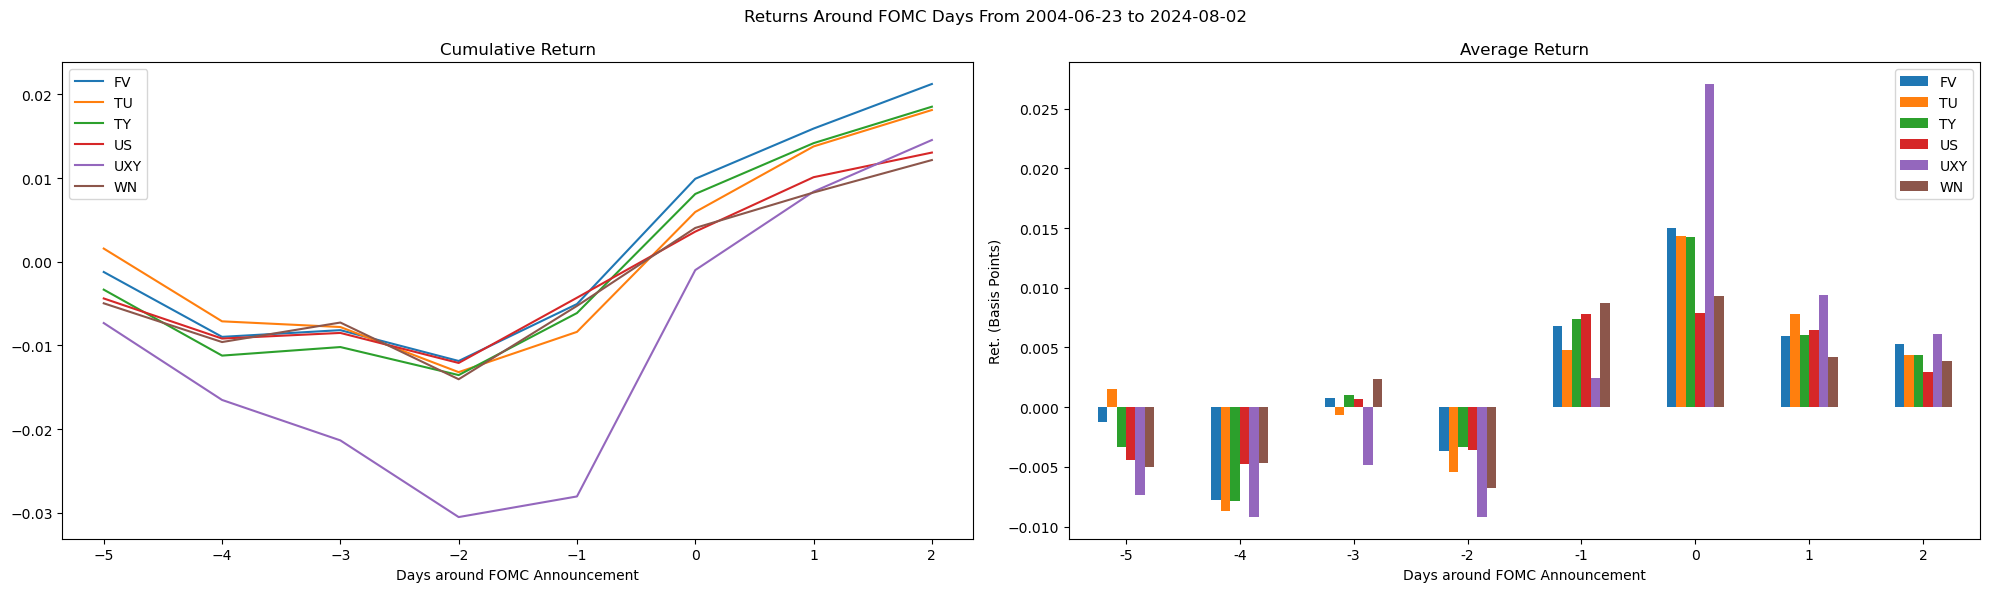

In [7]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_combined.drop(
    columns = ["event", "date"]).
    groupby(["day", "security"]).
    agg("mean").
    reset_index().
    rename(columns = {"security": ""}).
    pivot(index = "day", columns = "", values = "PX_bps").
    cumsum().
    plot(
        xlabel = "Cuml. Ret. (Basis Points)",
        ax     = axes[0],
        title  = "Cumulative Return"))

(df_avg_rtn.rename(columns = {
    "security": ""}).
    pivot(index = "day", columns = "", values = "avg_rtn").
    plot(
        kind   = "bar",
        ax     = axes[1],
        rot    = 0,
        ylabel = "Ret. (Basis Points)",
        title  = "Average Return"))

for ax in axes.flatten():
    ax.set_xlabel("Days around FOMC Announcement")

fig.suptitle("Returns Around FOMC Days From {} to {}".format(
    df_combined.date.min(),
    df_combined.date.max()))
plt.tight_layout()

Based on the cumulative basis points graph above start with a simple playback strategy of shorting Treasury Futures 5 days before and then flipping long 2 days before FOMC announcement. 

In [8]:
df_naive_signal = (df_combined.groupby(
    ["date", "security"]).
    head(1).
    assign(signal_rtn = lambda x: np.where(x.day <= -2, -x.PX_bps, x.PX_bps)))

In [9]:
df_avg_signal = (df_combined.groupby(
    ["date", "security"]).
    head(1).
    merge(right = df_avg_rtn, how = "inner", on = ["day", "security"]).
    assign(signal_rtn = lambda x: np.sign(x.avg_rtn) * x.PX_bps))

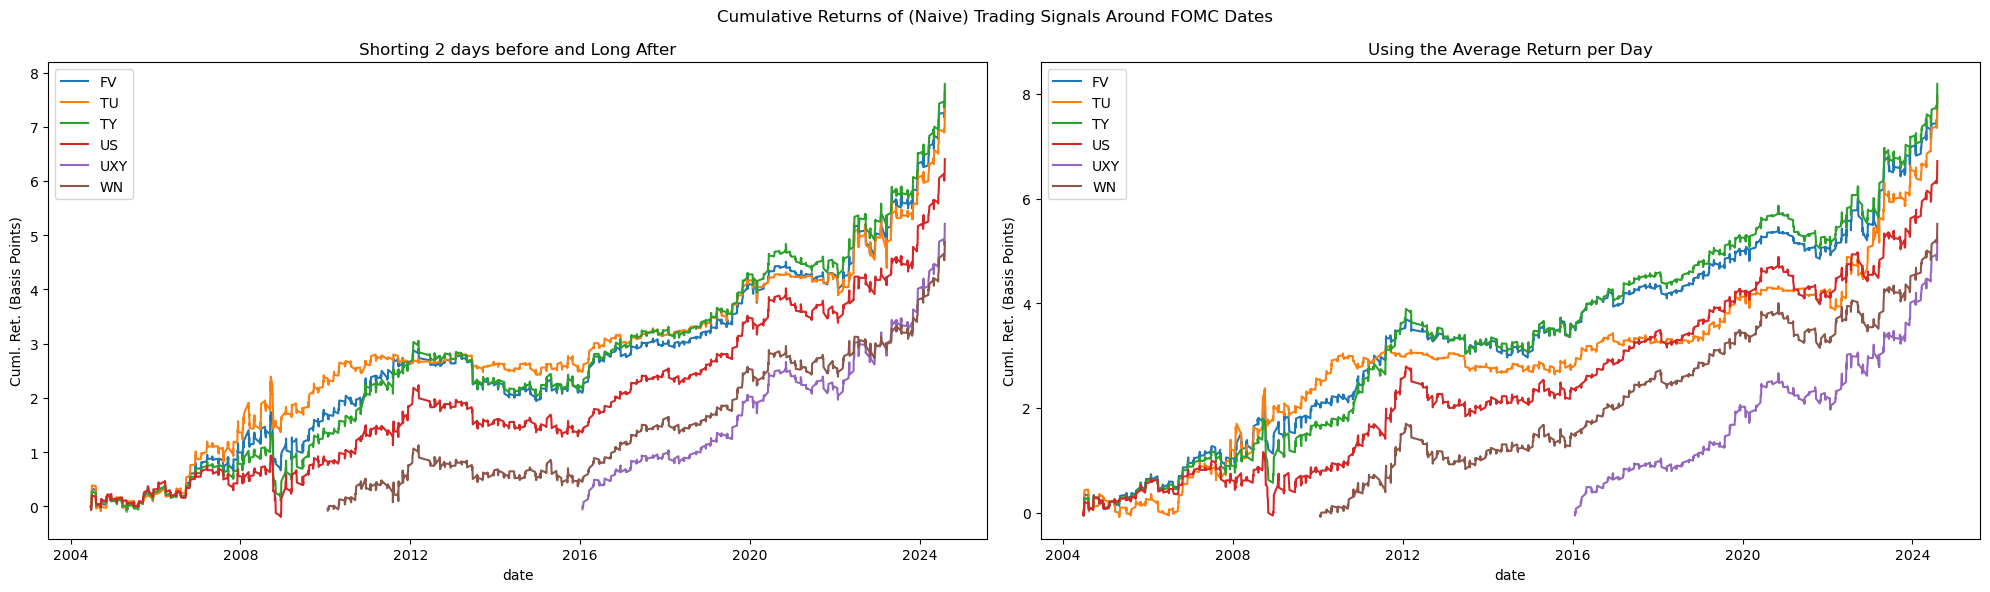

In [10]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_naive_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[0],
        title = "Shorting 2 days before and Long After"))

(df_avg_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[1],
        title = "Using the Average Return per Day"))

for ax in axes.flatten():
    ax.set_ylabel("Cuml. Ret. (Basis Points)")

fig.suptitle("Cumulative Returns of (Naive) Trading Signals Around FOMC Dates")
plt.tight_layout()

In [11]:
df_combined_strat = (pd.concat([
    df_naive_signal.assign(name = "raw_val"),
    df_avg_signal.assign(name = "avg_val")]))

In [12]:
df_strat_sharpe = (df_combined_strat[
    ["signal_rtn", "security", "name"]].
    groupby(["security", "name"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

In [13]:
df_tmp_sharpe = (df_combined_strat[
    ["date", "security", "PX_bps"]].
    drop_duplicates().
    drop(columns = ["date"]).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"PX_bps": "tmp_sharpe"}))

In [14]:
df_full_sharpe = (df_tsy[
    ["security", "PX_bps"]].
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"PX_bps": "full_sharpe"}))

In [15]:
(df_strat_sharpe.pivot(
    index = "security", columns = "name", values = "signal_rtn").
    merge(right = df_tmp_sharpe, how = "inner", on = ["security"]).
    merge(right = df_full_sharpe, how = "inner", on = ["security"]).
    T.
    assign(Avg = lambda x: x.mean(axis = 1)).
    T.
    rename(columns = {
        "avg_val"    : "Avg. Ret. Strat",
        "raw_val"    : "Naive Strat",
        "tmp_sharpe" : "Sharpe around FOMC",
        "full_sharpe": "Full Hist Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Avg. Ret. Strat,Naive Strat,Sharpe around FOMC,Full Hist Sharpe
security,,,,
FV,1.623,1.557,0.775,0.304
TU,1.606,1.512,0.645,0.282
TY,1.708,1.623,0.701,0.279
US,1.548,1.474,0.574,0.166
UXY,2.750,2.750,0.519,-0.215
WN,1.799,1.587,0.540,0.045
Avg,1.839,1.751,0.626,0.144


Now run the average returns analysis out of sample, which is done by taking the rolling out of sample average and then applying it to the next FOMC announcement

In [31]:
df_oos = (df_combined.pivot(
    index = "event", columns = ["day", "security"], values = "PX_bps").
    expanding().
    mean().
    shift().
    reset_index().
    melt(id_vars = [("event", "")], value_name = "signal").
    rename(columns = {("event", ""): "event"}).
    merge(right = df_combined, how = "inner", on = ["event", "day", "security"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.PX_bps))

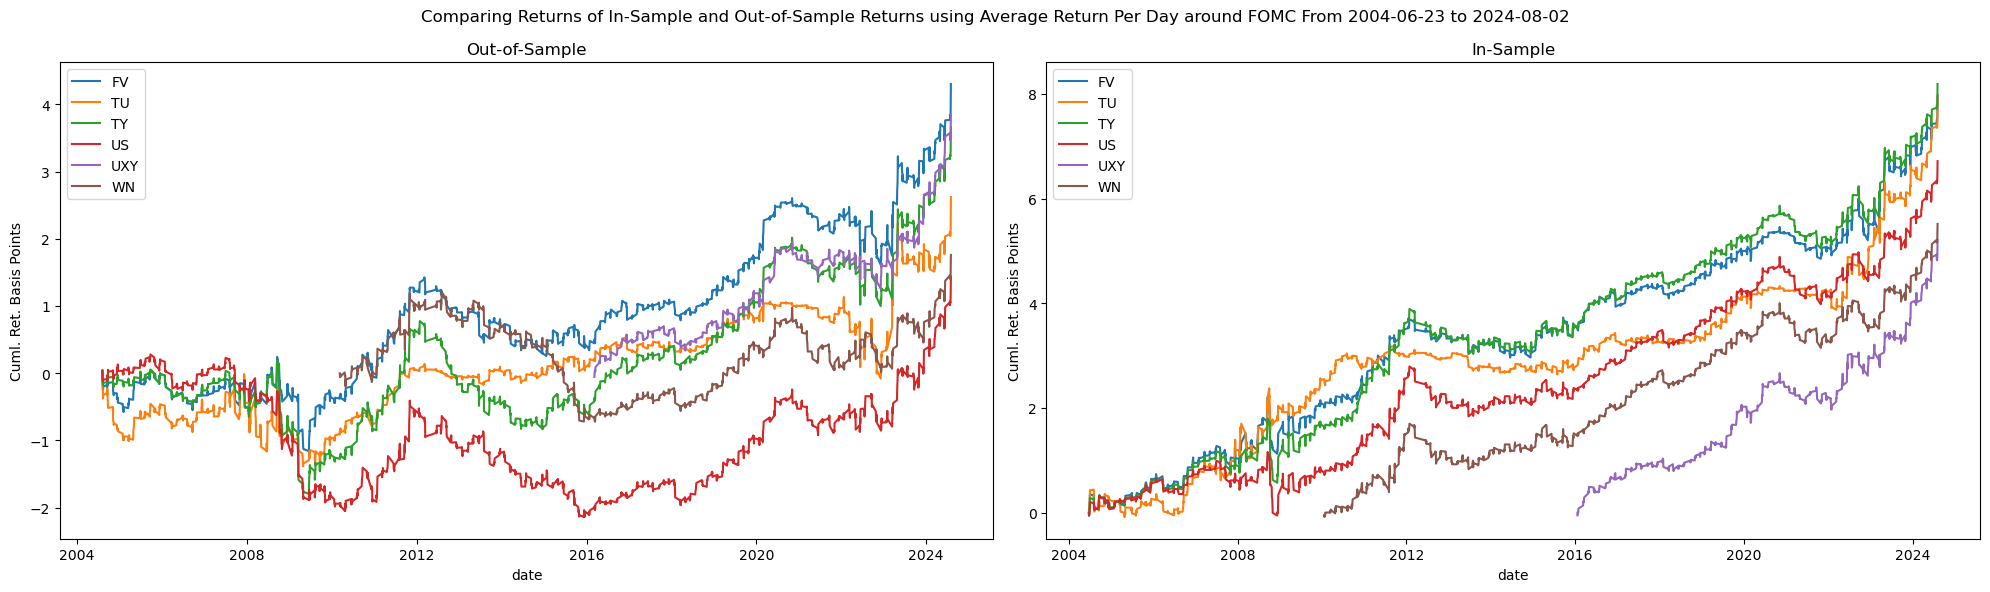

In [52]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_oos.groupby([
    "date", "security"]).
    head(1).
    dropna().
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[0],
        title = "Out-of-Sample"))

(df_avg_signal.
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    cumsum().
    plot(
        ax    = axes[1],
        title = "In-Sample"))

for ax in axes.flatten():
    ax.set_ylabel("Cuml. Ret. Basis Points")

fig.suptitle("Comparing Returns of In-Sample and Out-of-Sample Returns using Average Return Per Day around FOMC From {} to {}".format(
    df_oos.date.min(),
    df_oos.date.max()))

plt.tight_layout()

In [71]:
(pd.concat([
    df_oos.assign(group = "oos"),
    df_avg_signal.assign(group = "is")])
    [["security", "group", "signal_rtn"]].
    groupby(["security", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"group": ""}).
    pivot(index = "security", columns = "", values = "signal_rtn").
    assign(tmp = lambda x: x.is))

SyntaxError: invalid syntax (834972300.py, line 10)